# Exploração KDD | Preços de Combustíveis ANP (Silver)

Protótipo de exploração conectando direto no bucket `silver` do Minio, sem download manual.

Etapas:
1. **Seleção**: conectar e listar os dados disponíveis
2. **Pré-processamento**: schema, tipos, nulos, duplicatas
3. **Transformação**: normalização de texto, tipagem fina
4. **Mineração/Exploração**: estatísticas descritivas, distribuições
5. **Interpretação**: primeiras observações sobre os dados


## 0. Setup — conexão com o Minio

In [ ]:
import pandas as pd
import s3fs
from dotenv import load_dotenv
import os
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error
import numpy as np
import pandas as pd
import ruptures as rpt
import matplotlib.pyplot as plt
import seaborn as sns

load_dotenv()

MINIO_ENDPOINT = os.environ["MINIO_ENDPOINT"]
MINIO_ACCESS_KEY = os.environ["MINIO_ROOT_USER"]
MINIO_SECRET_KEY = os.environ["MINIO_ROOT_PASSWORD"]

fs = s3fs.S3FileSystem(
    key=MINIO_ACCESS_KEY,
    secret=MINIO_SECRET_KEY,
    client_kwargs={"endpoint_url": MINIO_ENDPOINT},
)


arquivos = fs.ls("silver/anp/municipios/")
print(f"{len(arquivos)} arquivos encontrados no silver")
arquivos[:5]


194 arquivos encontrados no silver


['silver/anp/municipios/Resumo_SEMANAL_LPC_2023.12.31_2024.01.06.parquet',
 'silver/anp/municipios/Resumo_SEMANAL_LPC_2024.04.14_2024.04.20.parquet',
 'silver/anp/municipios/Resumo_SEMANAL_LPC_2024.12.22_2024.12.28.parquet',
 'silver/anp/municipios/resumo_semanal_lpc-1.parquet',
 'silver/anp/municipios/resumo_semanal_lpc-17112025-a-23112025.parquet']

## 1. Seleção do df

In [49]:
# Usado inicialmente para testar lógica de verificação dos dados, depois, df foi expandido para considerar as outras abas da planilha ANP
df = pd.read_parquet("silver/anp/municipios/", filesystem=fs)

print(f"Shape: {df.shape}")
df.head()

Shape: (445373, 13)


,DATA INICIAL,DATA FINAL,ESTADO,MUNICÍPIO,PRODUTO,NÚMERO DE POSTOS PESQUISADOS,UNIDADE DE MEDIDA,PREÇO MÉDIO REVENDA,DESVIO PADRÃO REVENDA,PREÇO MÍNIMO REVENDA,PREÇO MÁXIMO REVENDA,COEF DE VARIAÇÃO REVENDA,ARQUIVO_ORIGEM
0,2023-12-31,2024-01-06,MARANHAO,ACAILANDIA,ETANOL HIDRATADO,4,R$/l,4.46,0.125831,4.29,4.59,0.028,Resumo_SEMANAL_LPC_2023.12.31_2024.01.06.xlsx
1,2023-12-31,2024-01-06,SAO PAULO,ADAMANTINA,ETANOL HIDRATADO,8,R$/l,2.87,0.133517,2.76,3.14,0.046,Resumo_SEMANAL_LPC_2023.12.31_2024.01.06.xlsx
2,2023-12-31,2024-01-06,GOIAS,AGUAS LINDAS DE GOIAS,ETANOL HIDRATADO,8,R$/l,3.89,0.000000,3.89,3.89,0.000,Resumo_SEMANAL_LPC_2023.12.31_2024.01.06.xlsx
3,2023-12-31,2024-01-06,BAHIA,ALAGOINHAS,ETANOL HIDRATADO,8,R$/l,3.68,0.163707,3.50,3.98,0.044,Resumo_SEMANAL_LPC_2023.12.31_2024.01.06.xlsx
4,2023-12-31,2024-01-06,RIO GRANDE DO SUL,ALEGRETE,ETANOL HIDRATADO,1,R$/l,4.99,0.000000,4.99,4.99,0.000,Resumo_SEMANAL_LPC_2023.12.31_2024.01.06.xlsx


In [50]:
df_estados = pd.read_parquet("silver/anp/estados/", filesystem=fs)
print(f"Shape (estados): {df_estados.shape}")
df_estados.head()

Shape (estados): (34545, 13)


,DATA INICIAL,DATA FINAL,REGIAO,ESTADOS,PRODUTO,NÚMERO DE POSTOS PESQUISADOS,UNIDADE DE MEDIDA,PREÇO MÉDIO REVENDA,DESVIO PADRÃO REVENDA,PREÇO MÍNIMO REVENDA,PREÇO MÁXIMO REVENDA,COEF DE VARIAÇÃO REVENDA,ARQUIVO_ORIGEM
0,2023-12-31,2024-01-06,NORTE,ACRE,ETANOL HIDRATADO,10,R$/l,4.76,0.358,4.49,5.79,0.075,Resumo_SEMANAL_LPC_2023.12.31_2024.01.06.xlsx
1,2023-12-31,2024-01-06,NORDESTE,ALAGOAS,ETANOL HIDRATADO,53,R$/l,3.72,0.565,3.49,5.80,0.152,Resumo_SEMANAL_LPC_2023.12.31_2024.01.06.xlsx
2,2023-12-31,2024-01-06,NORTE,AMAPA,ETANOL HIDRATADO,1,R$/l,5.34,0.000,5.34,5.34,0.000,Resumo_SEMANAL_LPC_2023.12.31_2024.01.06.xlsx
3,2023-12-31,2024-01-06,NORTE,AMAZONAS,ETANOL HIDRATADO,43,R$/l,4.29,0.194,4.15,4.86,0.045,Resumo_SEMANAL_LPC_2023.12.31_2024.01.06.xlsx
4,2023-12-31,2024-01-06,NORDESTE,BAHIA,ETANOL HIDRATADO,267,R$/l,4.08,0.313,3.50,4.99,0.077,Resumo_SEMANAL_LPC_2023.12.31_2024.01.06.xlsx


In [51]:
df_regioes = pd.read_parquet("silver/anp/regioes/", filesystem=fs)
print(f"Shape (regioes): {df_regioes.shape}")
df_regioes.head()

Shape (regioes): (6775, 12)


,DATA INICIAL,DATA FINAL,REGIAO,PRODUTO,NÚMERO DE POSTOS PESQUISADOS,UNIDADE DE MEDIDA,PREÇO MÉDIO REVENDA,DESVIO PADRÃO REVENDA,PREÇO MÍNIMO REVENDA,PREÇO MÁXIMO REVENDA,COEF DE VARIAÇÃO REVENDA,ARQUIVO_ORIGEM
0,2023-12-31,2024-01-06,CENTRO OESTE,ETANOL HIDRATADO,269,R$/l,3.07,0.354,2.79,4.70,0.115,Resumo_SEMANAL_LPC_2023.12.31_2024.01.06.xlsx
1,2023-12-31,2024-01-06,NORDESTE,ETANOL HIDRATADO,856,R$/l,3.99,0.415,3.39,5.80,0.104,Resumo_SEMANAL_LPC_2023.12.31_2024.01.06.xlsx
2,2023-12-31,2024-01-06,NORTE,ETANOL HIDRATADO,173,R$/l,4.30,0.556,3.73,6.60,0.129,Resumo_SEMANAL_LPC_2023.12.31_2024.01.06.xlsx
3,2023-12-31,2024-01-06,SUDESTE,ETANOL HIDRATADO,1989,R$/l,3.35,0.431,2.74,5.19,0.129,Resumo_SEMANAL_LPC_2023.12.31_2024.01.06.xlsx
4,2023-12-31,2024-01-06,SUL,ETANOL HIDRATADO,558,R$/l,3.75,0.509,3.13,5.99,0.136,Resumo_SEMANAL_LPC_2023.12.31_2024.01.06.xlsx


In [52]:
df_capitais = pd.read_parquet("silver/anp/capitais/", filesystem=fs)
print(f"Shape (capitais): {df_capitais.shape}")
df_capitais.head()

Shape (capitais): (32630, 13)


,DATA INICIAL,DATA FINAL,ESTADO,MUNICÍPIO,PRODUTO,NÚMERO DE POSTOS PESQUISADOS,UNIDADE DE MEDIDA,PREÇO MÉDIO REVENDA,DESVIO PADRÃO REVENDA,PREÇO MÍNIMO REVENDA,PREÇO MÁXIMO REVENDA,COEF DE VARIAÇÃO REVENDA,ARQUIVO_ORIGEM
0,2023-12-31,2024-01-06,SERGIPE,ARACAJU,ETANOL HIDRATADO,16,R$/l,4.01,0.272402,3.75,4.49,0.068,Resumo_SEMANAL_LPC_2023.12.31_2024.01.06.xlsx
1,2023-12-31,2024-01-06,PARA,BELEM,ETANOL HIDRATADO,12,R$/l,4.07,0.385518,3.85,5.19,0.095,Resumo_SEMANAL_LPC_2023.12.31_2024.01.06.xlsx
2,2023-12-31,2024-01-06,MINAS GERAIS,BELO HORIZONTE,ETANOL HIDRATADO,38,R$/l,3.36,0.143012,3.15,3.69,0.042,Resumo_SEMANAL_LPC_2023.12.31_2024.01.06.xlsx
3,2023-12-31,2024-01-06,RORAIMA,BOA VISTA,ETANOL HIDRATADO,4,R$/l,4.84,0.063966,4.79,4.92,0.013,Resumo_SEMANAL_LPC_2023.12.31_2024.01.06.xlsx
4,2023-12-31,2024-01-06,DISTRITO FEDERAL,BRASILIA,ETANOL HIDRATADO,38,R$/l,3.55,0.142938,3.29,3.75,0.040,Resumo_SEMANAL_LPC_2023.12.31_2024.01.06.xlsx


In [53]:
df_brasil = pd.read_parquet("silver/anp/brasil/", filesystem=fs)
print(f"Shape (brasil): {df_brasil.shape}")
df_brasil.head()

Shape (brasil): (1358, 12)


,DATA INICIAL,DATA FINAL,BRASIL,PRODUTO,NÚMERO DE POSTOS PESQUISADOS,UNIDADE DE MEDIDA,PREÇO MÉDIO REVENDA,DESVIO PADRÃO REVENDA,PREÇO MÍNIMO REVENDA,PREÇO MÁXIMO REVENDA,COEF DE VARIAÇÃO REVENDA,ARQUIVO_ORIGEM
0,2023-12-31,2024-01-06,BRASIL,ETANOL HIDRATADO,3845,R$/l,3.39,0.557,2.74,6.60,0.164,Resumo_SEMANAL_LPC_2023.12.31_2024.01.06.xlsx
1,2023-12-31,2024-01-06,BRASIL,GASOLINA ADITIVADA,3619,R$/l,5.76,0.405,4.77,8.69,0.070,Resumo_SEMANAL_LPC_2023.12.31_2024.01.06.xlsx
2,2023-12-31,2024-01-06,BRASIL,GASOLINA COMUM,4554,R$/l,5.56,0.396,4.58,7.69,0.071,Resumo_SEMANAL_LPC_2023.12.31_2024.01.06.xlsx
3,2023-12-31,2024-01-06,BRASIL,GLP,4527,R$/13kg,100.77,12.885,67.00,154.00,0.128,Resumo_SEMANAL_LPC_2023.12.31_2024.01.06.xlsx
4,2023-12-31,2024-01-06,BRASIL,GNV,364,R$/m³,4.49,0.471,3.89,6.29,0.105,Resumo_SEMANAL_LPC_2023.12.31_2024.01.06.xlsx


# Perguntas Exploradas na Etapa de KDD

1. **Existe alguma variação de schema/colunas entre os 194 arquivos ao longo do tempo?**
   Resolvido: schema estável, 1 exceção com colunas vazias extras.

2. **Os arquivos abrem corretamente via processamento programático?**
   Resolvido: 9 arquivos malformados (formato OOXML "strict"), corrigidos via fallback LibreOffice.

3. **O dado tem nulos, duplicatas, ou inconsistências de tipo?**
   Resolvido: zero nulos, zero duplicatas, tipos corretos desde a extração.

4. **`ESTADO`/`MUNICÍPIO` têm inconsistência de acentuação ou maiúsculas entre arquivos de períodos diferentes?**
   Resolvido: zero inconsistências, dado já padronizado pela fonte.

5. **A regra MÍNIMO ≤ MÉDIO ≤ MÁXIMO se sustenta em todas as linhas?**
   Resolvido: zero violações.

6. **Como o preço varia por produto (distribuição, faixas)?**
   Explorado: distribuição condizente com o mercado real; identificadas unidades de medida distintas (R$/l, R$/13kg, R$/m³).

7. **Como o preço evoluiu ao longo do tempo (2022-2026)?**
   Explorado: identificados saltos abruptos correspondentes a eventos tributários reais (ICMS, PIS/Cofins, política de preços da Petrobras).

8. **Esses saltos são detectáveis estatisticamente, sem conhecimento prévio da data?**
   Explorado via Teste de Chow e `ruptures`: sim, com boa precisão — uma das datas detectadas automaticamente ainda não tinha causa identificada (evento de fev/2026).

9. **É possível prever o preço futuro a partir do histórico (ML)?**
   Testado e descartado: modelo de regressão não superou o baseline naive em nenhum horizonte testado; eventos exógenos dominam a série.

10. **Quais estados têm o preço mais alto/baixo (ranking)?**
    Explorado, usando a aba oficial `ESTADOS`.

11. **Onde há maior disparidade de preço entre postos dentro do mesmo local (variabilidade)?**
    Explorado via `COEF DE VARIAÇÃO REVENDA`, usando a aba `CAPITAIS`.

12. **Como o preço se compara entre regiões do país ao longo do tempo?**
    Explorado usando a aba oficial `REGIOES`.

13. **Amapá (e estados de baixa cobertura amostral) têm lacunas de dado — é erro ou característica real?**
    Investigado: lacunas pontuais refletem amostra muito pequena (1-4 postos), não erro de pipeline.

14. **A capital de um estado é sempre mais cara que o interior?**
    Explorado: não — em vários estados (Maranhão, Pará, Mato Grosso do Sul) o interior é mais caro, provavelmente por custo logístico de distribuição.

15. **Existe sazonalidade de preço por mês do ano?**
    Explorado e descartado: variação mensal (~±5%) é majoritariamente reflexo da tendência de alta ao longo dos anos, sem padrão sazonal real.

16. **Qual produto tem a maior volatilidade de preço?**
    Explorado: depende da métrica — em termos absolutos é o GLP, mas em termos relativos (coeficiente de variação) é o Etanol Hidratado, o mais sensível a variações de safra.


## 2. Pré-processamento — schema, tipos, nulos

In [55]:
df_brasil.dtypes


DATA INICIAL                    datetime64[ns]
DATA FINAL                      datetime64[ns]
BRASIL                                     str
PRODUTO                                    str
NÚMERO DE POSTOS PESQUISADOS             int64
UNIDADE DE MEDIDA                          str
PREÇO MÉDIO REVENDA                    float64
DESVIO PADRÃO REVENDA                  float64
PREÇO MÍNIMO REVENDA                   float64
PREÇO MÁXIMO REVENDA                   float64
COEF DE VARIAÇÃO REVENDA               float64
ARQUIVO_ORIGEM                             str
dtype: object

In [56]:
df_capitais.dtypes

DATA INICIAL                    datetime64[ns]
DATA FINAL                      datetime64[ns]
ESTADO                                     str
MUNICÍPIO                                  str
PRODUTO                                    str
NÚMERO DE POSTOS PESQUISADOS             int64
UNIDADE DE MEDIDA                          str
PREÇO MÉDIO REVENDA                    float64
DESVIO PADRÃO REVENDA                  float64
PREÇO MÍNIMO REVENDA                   float64
PREÇO MÁXIMO REVENDA                   float64
COEF DE VARIAÇÃO REVENDA               float64
ARQUIVO_ORIGEM                             str
dtype: object

In [57]:
df_estados.dtypes

DATA INICIAL                    datetime64[ns]
DATA FINAL                      datetime64[ns]
REGIAO                                     str
ESTADOS                                    str
PRODUTO                                    str
NÚMERO DE POSTOS PESQUISADOS             int64
UNIDADE DE MEDIDA                          str
PREÇO MÉDIO REVENDA                    float64
DESVIO PADRÃO REVENDA                  float64
PREÇO MÍNIMO REVENDA                   float64
PREÇO MÁXIMO REVENDA                   float64
COEF DE VARIAÇÃO REVENDA               float64
ARQUIVO_ORIGEM                             str
dtype: object

In [ ]:
df.dtypes


DATA INICIAL                    datetime64[ns]
DATA FINAL                      datetime64[ns]
ESTADO                                     str
MUNICÍPIO                                  str
PRODUTO                                    str
NÚMERO DE POSTOS PESQUISADOS             int64
UNIDADE DE MEDIDA                          str
PREÇO MÉDIO REVENDA                    float64
DESVIO PADRÃO REVENDA                  float64
PREÇO MÍNIMO REVENDA                   float64
PREÇO MÁXIMO REVENDA                   float64
COEF DE VARIAÇÃO REVENDA               float64
ARQUIVO_ORIGEM                             str
dtype: object

In [6]:
df.isnull().sum()


DATA INICIAL                    0
DATA FINAL                      0
ESTADO                          0
MUNICÍPIO                       0
PRODUTO                         0
NÚMERO DE POSTOS PESQUISADOS    0
UNIDADE DE MEDIDA               0
PREÇO MÉDIO REVENDA             0
DESVIO PADRÃO REVENDA           0
PREÇO MÍNIMO REVENDA            0
PREÇO MÁXIMO REVENDA            0
COEF DE VARIAÇÃO REVENDA        0
ARQUIVO_ORIGEM                  0
dtype: int64

In [7]:
# Confere se há duplicatas exatas
chave = ["DATA INICIAL", "DATA FINAL", "ESTADO", "MUNICÍPIO", "PRODUTO"]
duplicatas = df.duplicated(subset=chave).sum()
print(f"Linhas duplicadas pela chave natural: {duplicatas}")


Linhas duplicadas pela chave natural: 0


## 3. Transformação

In [8]:
import unicodedata

def normalizar_texto(serie: pd.Series) -> pd.Series:
    """Remove acentos e padroniza maiúsculas — mesma lógica que vai para o Spark."""
    return (
        serie.str.upper()
        .str.normalize("NFKD")
        .str.encode("ascii", errors="ignore")
        .str.decode("utf-8")
    )

df["ESTADO_NORM"] = normalizar_texto(df["ESTADO"])
df["MUNICIPIO_NORM"] = normalizar_texto(df["MUNICÍPIO"])

df[["ESTADO", "ESTADO_NORM", "MUNICÍPIO", "MUNICIPIO_NORM"]].drop_duplicates().head(10)


,ESTADO,ESTADO_NORM,MUNICÍPIO,MUNICIPIO_NORM
0,MARANHAO,MARANHAO,ACAILANDIA,ACAILANDIA
1,SAO PAULO,SAO PAULO,ADAMANTINA,ADAMANTINA
2,GOIAS,GOIAS,AGUAS LINDAS DE GOIAS,AGUAS LINDAS DE GOIAS
3,BAHIA,BAHIA,ALAGOINHAS,ALAGOINHAS
4,RIO GRANDE DO SUL,RIO GRANDE DO SUL,ALEGRETE,ALEGRETE
5,PARA,PARA,ALENQUER,ALENQUER
6,MINAS GERAIS,MINAS GERAIS,ALFENAS,ALFENAS
7,PARA,PARA,ALTAMIRA,ALTAMIRA
8,RIO GRANDE DO SUL,RIO GRANDE DO SUL,ALVORADA,ALVORADA
9,SAO PAULO,SAO PAULO,AMERICANA,AMERICANA


In [9]:
diferentes_estado = (df["ESTADO"] != df["ESTADO_NORM"]).sum()
diferentes_municipio = (df["MUNICÍPIO"] != df["MUNICIPIO_NORM"]).sum()

print(f"Linhas com ESTADO diferente do normalizado: {diferentes_estado}")
print(f"Linhas com MUNICÍPIO diferente do normalizado: {diferentes_municipio}")

Linhas com ESTADO diferente do normalizado: 0
Linhas com MUNICÍPIO diferente do normalizado: 0


In [12]:
colunas_numericas = [
    "NÚMERO DE POSTOS PESQUISADOS",
    "PREÇO MÉDIO REVENDA",
    "DESVIO PADRÃO REVENDA",
    "PREÇO MÍNIMO REVENDA",
    "PREÇO MÁXIMO REVENDA",
    "COEF DE VARIAÇÃO REVENDA",
]

for col in colunas_numericas:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["DATA INICIAL"] = pd.to_datetime(df["DATA INICIAL"])
df["DATA FINAL"] = pd.to_datetime(df["DATA FINAL"])

df.dtypes


DATA INICIAL                    datetime64[ns]
DATA FINAL                      datetime64[ns]
ESTADO                                     str
MUNICÍPIO                                  str
PRODUTO                                    str
NÚMERO DE POSTOS PESQUISADOS             int64
UNIDADE DE MEDIDA                          str
PREÇO MÉDIO REVENDA                    float64
DESVIO PADRÃO REVENDA                  float64
PREÇO MÍNIMO REVENDA                   float64
PREÇO MÁXIMO REVENDA                   float64
COEF DE VARIAÇÃO REVENDA               float64
ARQUIVO_ORIGEM                             str
ESTADO_NORM                                str
MUNICIPIO_NORM                             str
dtype: object

## 4. Mineração/Exploração — estatísticas e distribuições

In [15]:
df.groupby("PRODUTO")["PREÇO MÉDIO REVENDA"].describe()

,count,mean,std,min,25%,50%,75%,max
PRODUTO,,,,,,,,
ETANOL HIDRATADO,72745.0,4.334562,0.570754,2.75,3.91,4.33,4.74,6.60
GASOLINA ADITIVADA,73344.0,6.188129,0.537346,4.57,5.83,6.19,6.54,9.11
GASOLINA COMUM,74040.0,6.017257,0.543830,4.46,5.65,6.00,6.36,9.10
GLP,61881.0,107.769126,11.592116,67.71,99.81,106.88,115.00,154.25
GNV,22231.0,4.840291,0.536440,3.15,4.49,4.79,5.09,6.99
OLEO DIESEL,67690.0,6.109298,0.571898,4.39,5.81,6.04,6.37,9.27
OLEO DIESEL S10,73442.0,6.216261,0.592729,4.45,5.91,6.12,6.47,9.45


In [16]:
df.groupby("PRODUTO")["UNIDADE DE MEDIDA"].unique()

PRODUTO
ETANOL HIDRATADO         [R$/l]
GASOLINA ADITIVADA       [R$/l]
GASOLINA COMUM           [R$/l]
GLP                   [R$/13kg]
GNV                     [R$/m³]
OLEO DIESEL              [R$/l]
OLEO DIESEL S10          [R$/l]
Name: UNIDADE DE MEDIDA, dtype: object

In [14]:
df["PRODUTO"].value_counts()


PRODUTO
GASOLINA COMUM        74040
OLEO DIESEL S10       73442
GASOLINA ADITIVADA    73344
ETANOL HIDRATADO      72745
OLEO DIESEL           67690
GLP                   61881
GNV                   22231
Name: count, dtype: int64

In [ ]:
# Checagem de consistência: MÍNIMO <= MÉDIO <= MÁXIMO
inconsistentes = df[
    (df["PREÇO MÍNIMO REVENDA"] > df["PREÇO MÉDIO REVENDA"])
    | (df["PREÇO MÉDIO REVENDA"] > df["PREÇO MÁXIMO REVENDA"])
]
print(f"Linhas inconsistentes: {len(inconsistentes)}")
inconsistentes.head()


Linhas inconsistentes: 0


,DATA INICIAL,DATA FINAL,ESTADO,MUNICÍPIO,PRODUTO,NÚMERO DE POSTOS PESQUISADOS,UNIDADE DE MEDIDA,PREÇO MÉDIO REVENDA,DESVIO PADRÃO REVENDA,PREÇO MÍNIMO REVENDA,PREÇO MÁXIMO REVENDA,COEF DE VARIAÇÃO REVENDA,ARQUIVO_ORIGEM,ESTADO_NORM,MUNICIPIO_NORM


<Axes: title={'center': 'Evolução do preço médio nacional — Produtos em R$/litro'}, xlabel='DATA INICIAL'>

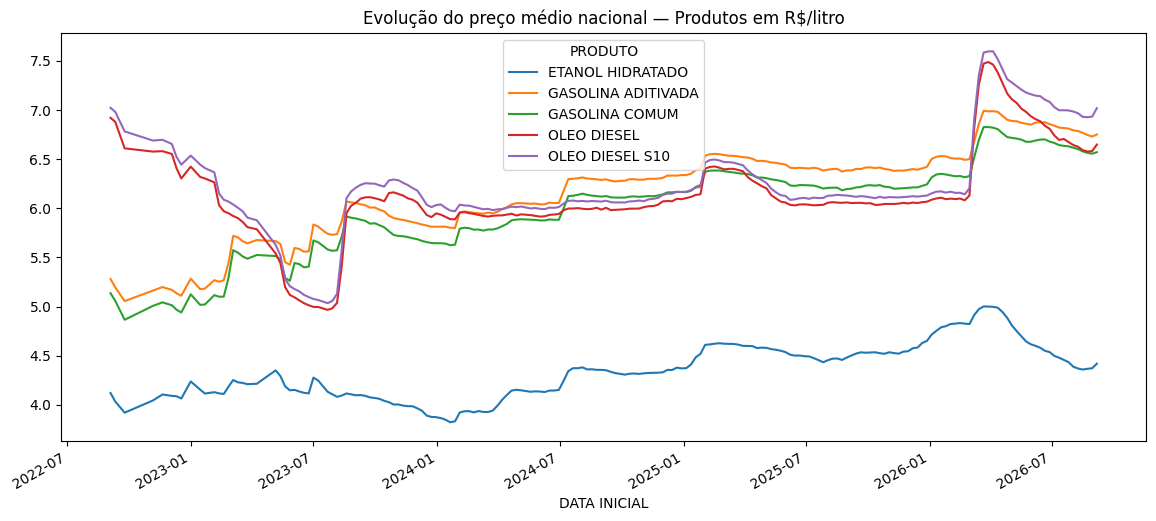

In [21]:
produtos_litro = ["GASOLINA COMUM", "ETANOL HIDRATADO", "GASOLINA ADITIVADA", "OLEO DIESEL S10", "OLEO DIESEL"]

df_litro = df[df["PRODUTO"].isin(produtos_litro)]

evolucao_litro = (
    df_litro
    .groupby(["DATA INICIAL", "PRODUTO"])["PREÇO MÉDIO REVENDA"]
    .mean()
    .unstack("PRODUTO")
)

evolucao_litro.plot(title="Evolução do preço médio nacional — Produtos em R$/litro", figsize=(14, 6))

Última semana disponível: 2026-09-06


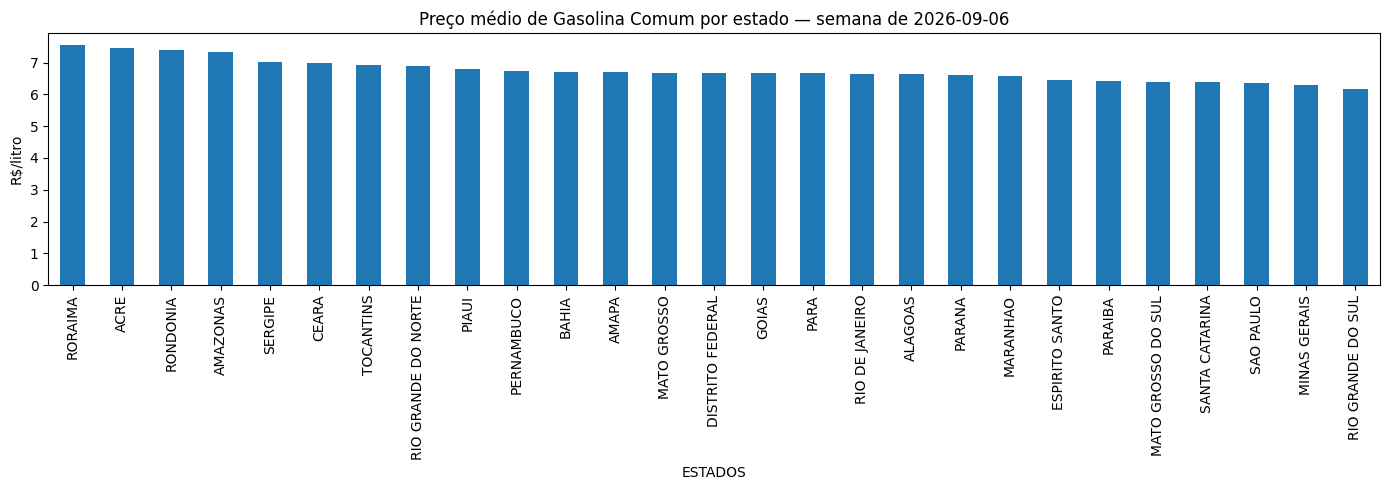

In [58]:
ultima_semana = df_estados["DATA INICIAL"].max()
print(f"Última semana disponível: {ultima_semana.date()}")

ranking = (
    df_estados[(df_estados["DATA INICIAL"] == ultima_semana) & (df_estados["PRODUTO"] == "GASOLINA COMUM")]
    .sort_values("PREÇO MÉDIO REVENDA", ascending=False)
    .set_index("ESTADOS")["PREÇO MÉDIO REVENDA"]
)

ranking.plot(kind="bar", figsize=(14, 5), title=f"Preço médio de Gasolina Comum por estado — semana de {ultima_semana.date()}")
plt.ylabel("R$/litro")
plt.tight_layout()

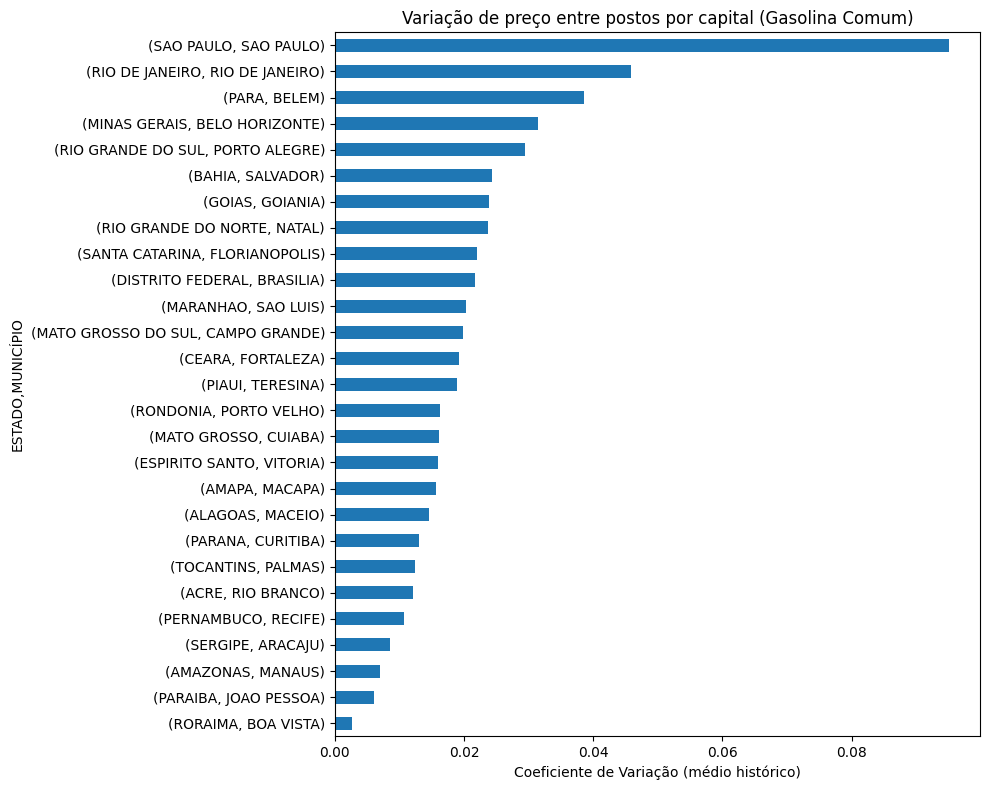

In [60]:
top_variabilidade_capitais = (
    df_capitais[df_capitais["PRODUTO"] == "GASOLINA COMUM"]
    .groupby(["ESTADO", "MUNICÍPIO"])["COEF DE VARIAÇÃO REVENDA"]
    .mean()
    .sort_values(ascending=False)
)

top_variabilidade_capitais.plot(kind="barh", figsize=(10, 8), title="Variação de preço entre postos por capital (Gasolina Comum)")
plt.xlabel("Coeficiente de Variação (médio histórico)")
plt.gca().invert_yaxis()
plt.tight_layout()

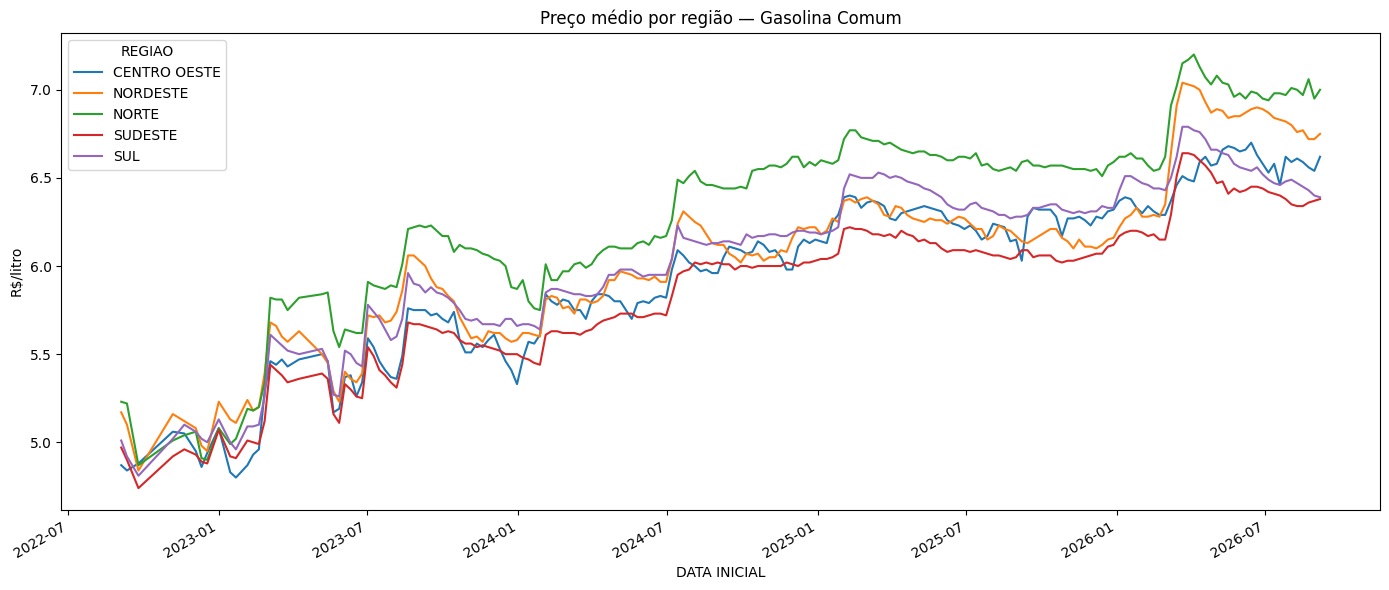

In [61]:
evolucao_regional = (
    df_regioes[df_regioes["PRODUTO"] == "GASOLINA COMUM"]
    .groupby(["DATA INICIAL", "REGIAO"])["PREÇO MÉDIO REVENDA"]
    .mean()
    .unstack("REGIAO")
)

evolucao_regional.plot(figsize=(14, 6), title="Preço médio por região — Gasolina Comum")
plt.ylabel("R$/litro")
plt.tight_layout()

In [62]:
ranking_todos_produtos = (
    df_estados[df_estados["DATA INICIAL"] == ultima_semana]
    .pivot_table(index="ESTADOS", columns="PRODUTO", values="PREÇO MÉDIO REVENDA")
)
ranking_todos_produtos

PRODUTO,ETANOL HIDRATADO,GASOLINA ADITIVADA,GASOLINA COMUM,GLP,GNV,OLEO DIESEL,OLEO DIESEL S10
ESTADOS,,,,,,,
ACRE,4.96,7.45,7.47,125.17,NaN,7.89,8.30
ALAGOAS,4.96,6.92,6.63,103.68,4.39,6.98,6.84
AMAPA,NaN,6.80,6.70,128.94,NaN,NaN,7.21
AMAZONAS,5.28,7.41,7.32,128.69,4.99,7.24,7.31
BAHIA,4.52,6.84,6.70,115.37,4.65,7.04,7.36
CEARA,5.00,7.13,6.98,114.92,5.55,7.19,7.03
DISTRITO FEDERAL,4.38,6.82,6.68,105.75,NaN,6.92,6.96
ESPIRITO SANTO,4.59,6.63,6.44,103.16,4.36,6.69,6.82
GOIAS,4.36,6.86,6.67,114.01,NaN,6.28,6.78


In [65]:
comparacao = pd.merge(
    df_capitais[df_capitais["PRODUTO"] == "GASOLINA COMUM"][["DATA INICIAL", "ESTADO", "PREÇO MÉDIO REVENDA"]],
    df_estados[df_estados["PRODUTO"] == "GASOLINA COMUM"][["DATA INICIAL", "ESTADOS", "PREÇO MÉDIO REVENDA"]],
    left_on=["DATA INICIAL", "ESTADO"],
    right_on=["DATA INICIAL", "ESTADOS"],
    suffixes=("_capital", "_estado"),
)
comparacao["diferenca"] = comparacao["PREÇO MÉDIO REVENDA_capital"] - comparacao["PREÇO MÉDIO REVENDA_estado"]
comparacao.groupby("ESTADO")["diferenca"].mean().sort_values(ascending=False)


ESTADO
PARANA                 0.200104
SANTA CATARINA         0.089312
TOCANTINS              0.066839
GOIAS                  0.059836
SERGIPE                0.033298
RONDONIA               0.030722
SAO PAULO              0.026495
PERNAMBUCO             0.005365
RORAIMA                0.000000
DISTRITO FEDERAL       0.000000
PARAIBA               -0.009175
AMAPA                 -0.012717
PIAUI                 -0.019072
RIO GRANDE DO NORTE   -0.024021
MINAS GERAIS          -0.024656
CEARA                 -0.029742
AMAZONAS              -0.036907
ALAGOAS               -0.042332
RIO GRANDE DO SUL     -0.083016
MATO GROSSO           -0.084611
RIO DE JANEIRO        -0.086134
ACRE                  -0.088634
BAHIA                 -0.119158
ESPIRITO SANTO        -0.147216
MATO GROSSO DO SUL    -0.153684
PARA                  -0.162434
MARANHAO              -0.215567
Name: diferenca, dtype: float64

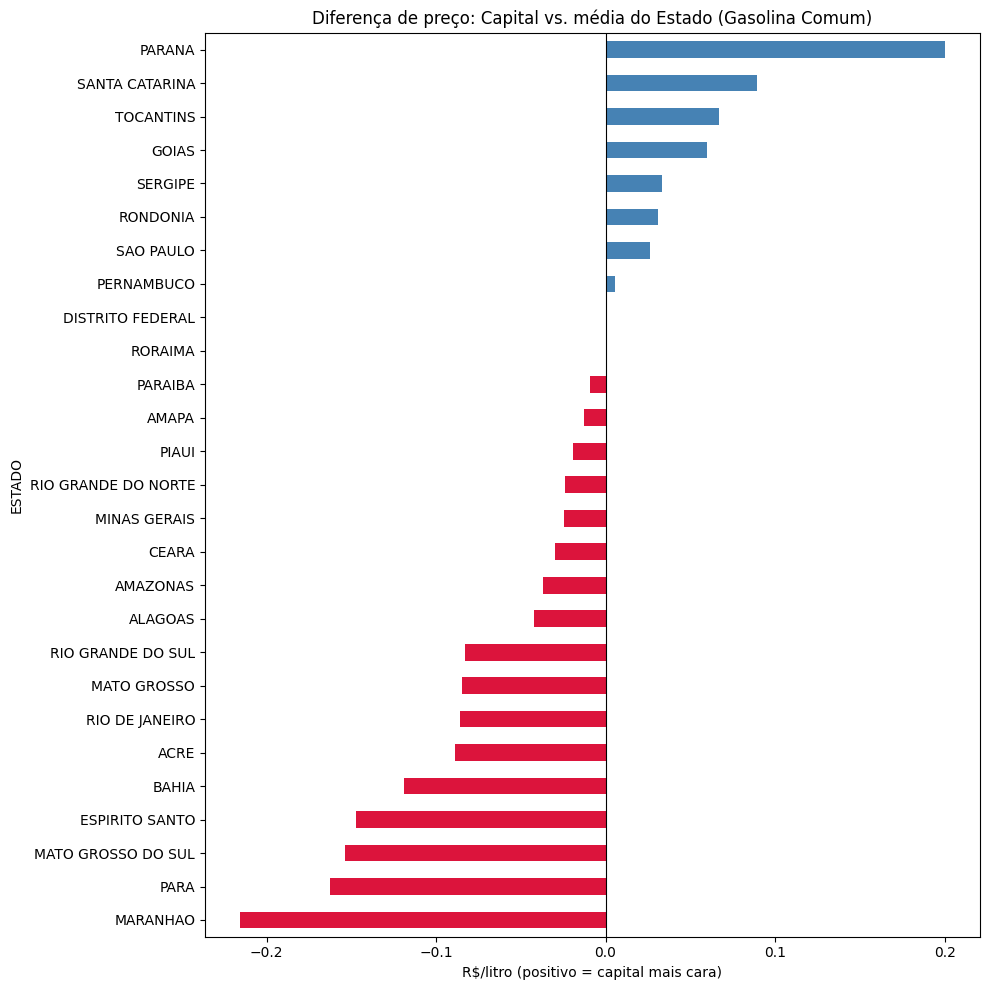

In [71]:
diferenca_ordenada = comparacao.groupby("ESTADO")["diferenca"].mean().sort_values()

plt.figure(figsize=(10, 10))
diferenca_ordenada.plot(kind="barh", color=diferenca_ordenada.apply(lambda x: "crimson" if x < 0 else "steelblue"))
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Diferença de preço: Capital vs. média do Estado (Gasolina Comum)")
plt.xlabel("R$/litro (positivo = capital mais cara)")
plt.tight_layout()

In [70]:
df[
    (df["ESTADO"] == "AMAPA") & (df["PRODUTO"] == "ETANOL HIDRATADO")
]

,DATA INICIAL,DATA FINAL,ESTADO,MUNICÍPIO,PRODUTO,NÚMERO DE POSTOS PESQUISADOS,UNIDADE DE MEDIDA,PREÇO MÉDIO REVENDA,DESVIO PADRÃO REVENDA,PREÇO MÍNIMO REVENDA,PREÇO MÁXIMO REVENDA,COEF DE VARIAÇÃO REVENDA,ARQUIVO_ORIGEM
352,2023-12-31,2024-01-06,AMAPA,SANTANA,ETANOL HIDRATADO,1,R$/l,5.34,0.000000,5.34,5.34,0.000,Resumo_SEMANAL_LPC_2023.12.31_2024.01.06.xlsx
3124,2024-04-14,2024-04-20,AMAPA,SANTANA,ETANOL HIDRATADO,1,R$/l,4.99,0.000000,4.99,4.99,0.000,Resumo_SEMANAL_LPC_2024.04.14_2024.04.20.xlsx
5748,2024-12-22,2024-12-28,AMAPA,MACAPA,ETANOL HIDRATADO,4,R$/l,5.28,0.254608,5.11,5.65,0.048,Resumo_SEMANAL_LPC_2024.12.22_2024.12.28.xlsx
9396,2025-11-16,2025-11-22,AMAPA,MACAPA,ETANOL HIDRATADO,1,R$/l,5.54,0.000000,5.54,5.54,0.000,resumo_semanal_lpc-17112025-a-23112025.xlsx
11526,2025-11-02,2025-11-08,AMAPA,MACAPA,ETANOL HIDRATADO,1,R$/l,5.54,0.000000,5.54,5.54,0.000,resumo_semanal_lpc-2.xlsx
...,...,...,...,...,...,...,...,...,...,...,...,...,...
426563,2026-07-19,2026-07-25,AMAPA,MACAPA,ETANOL HIDRATADO,1,R$/l,5.89,0.000000,5.89,5.89,0.000,resumo_semanal_lpc_2026-07-19_2026-07-25.xlsx
428935,2026-07-26,2026-08-01,AMAPA,MACAPA,ETANOL HIDRATADO,2,R$/l,5.81,0.000000,5.81,5.81,0.000,resumo_semanal_lpc_2026-07-26_2026-08-01.xlsx
436083,2026-08-16,2026-08-22,AMAPA,MACAPA,ETANOL HIDRATADO,3,R$/l,5.83,0.046188,5.81,5.89,0.008,resumo_semanal_lpc_2026-08-16_2026-08-22.xlsx
438498,2026-08-23,2026-08-29,AMAPA,MACAPA,ETANOL HIDRATADO,4,R$/l,5.93,0.190438,5.81,6.21,0.032,resumo_semanal_lpc_2026-08-23_2026-08-29.xlsx


In [67]:
df_estados[
    (df_estados["ESTADOS"] == "AMAPA") 
    & (df_estados["PRODUTO"] == "ETANOL HIDRATADO")
    & (df_estados["DATA INICIAL"] == ultima_semana)
]

,DATA INICIAL,DATA FINAL,REGIAO,ESTADOS,PRODUTO,NÚMERO DE POSTOS PESQUISADOS,UNIDADE DE MEDIDA,PREÇO MÉDIO REVENDA,DESVIO PADRÃO REVENDA,PREÇO MÍNIMO REVENDA,PREÇO MÁXIMO REVENDA,COEF DE VARIAÇÃO REVENDA,ARQUIVO_ORIGEM


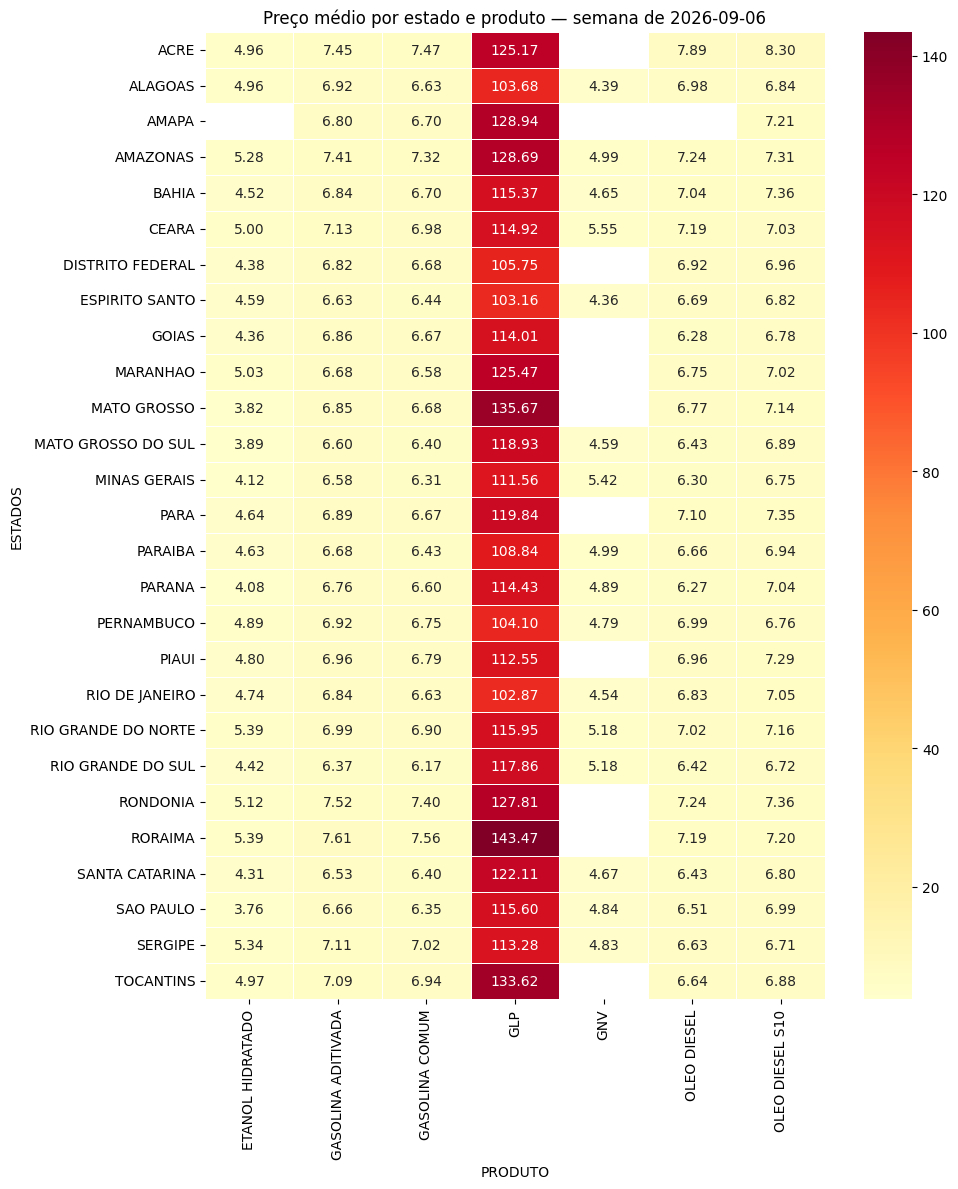

In [ ]:


plt.figure(figsize=(10, 12))
sns.heatmap(ranking_todos_produtos, annot=True, fmt=".2f", cmap="YlOrRd", linewidths=0.5)
plt.title(f"Preço médio por estado e produto — semana de {ultima_semana.date()}")
plt.tight_layout()

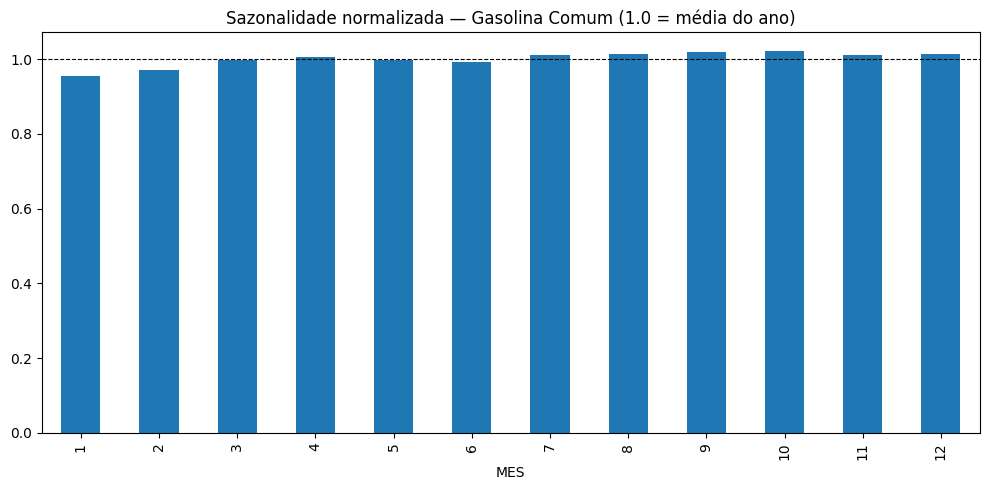

In [73]:
df_brasil["ANO"] = df_brasil["DATA INICIAL"].dt.year
df_brasil["MES"] = df_brasil["DATA INICIAL"].dt.month

# Preço relativo à média do próprio ano (remove a tendência de longo prazo)
media_anual = df_brasil[df_brasil["PRODUTO"] == "GASOLINA COMUM"].groupby("ANO")["PREÇO MÉDIO REVENDA"].transform("mean")
df_gasolina = df_brasil[df_brasil["PRODUTO"] == "GASOLINA COMUM"].copy()
df_gasolina["PRECO_RELATIVO"] = df_gasolina["PREÇO MÉDIO REVENDA"] / media_anual

sazonalidade_normalizada = df_gasolina.groupby("MES")["PRECO_RELATIVO"].mean()
sazonalidade_normalizada.plot(kind="bar", figsize=(10, 5), title="Sazonalidade normalizada — Gasolina Comum (1.0 = média do ano)")
plt.axhline(1.0, color="black", linewidth=0.8, linestyle="--")
plt.tight_layout()

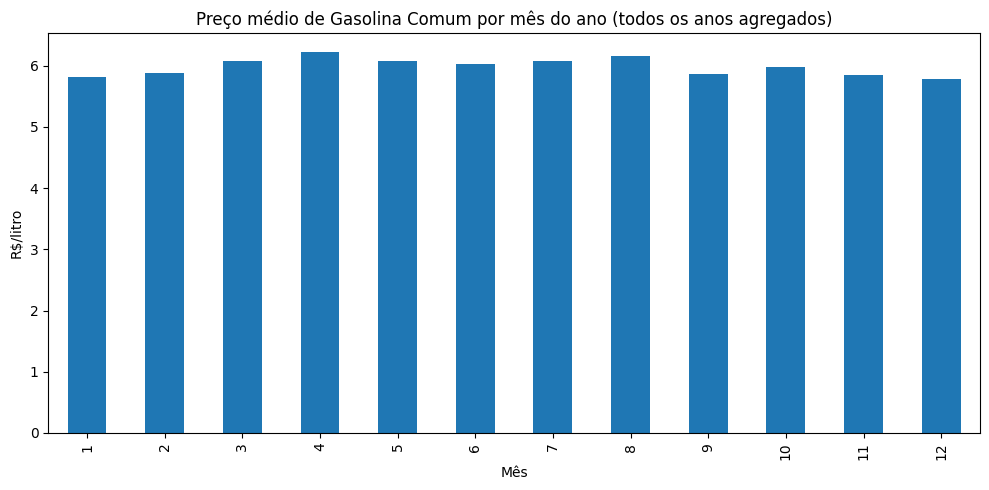

In [74]:
df_brasil["MES"] = df_brasil["DATA INICIAL"].dt.month

sazonalidade = (
    df_brasil[df_brasil["PRODUTO"] == "GASOLINA COMUM"]
    .groupby("MES")["PREÇO MÉDIO REVENDA"]
    .mean()
)

sazonalidade.plot(kind="bar", figsize=(10, 5), title="Preço médio de Gasolina Comum por mês do ano (todos os anos agregados)")
plt.xlabel("Mês")
plt.ylabel("R$/litro")
plt.tight_layout()

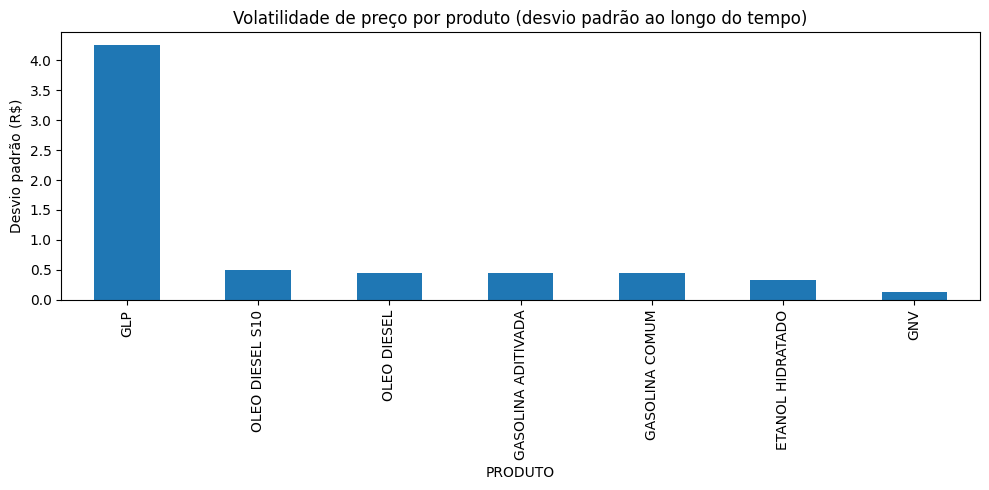

In [75]:
volatilidade_por_produto = (
    df_brasil.groupby("PRODUTO")["PREÇO MÉDIO REVENDA"]
    .std()
    .sort_values(ascending=False)
)

volatilidade_por_produto.plot(kind="bar", figsize=(10, 5), title="Volatilidade de preço por produto (desvio padrão ao longo do tempo)")
plt.ylabel("Desvio padrão (R$)")
plt.tight_layout()

<Axes: title={'center': 'Volatilidade relativa por produto (CV = desvio/média)'}, xlabel='PRODUTO'>

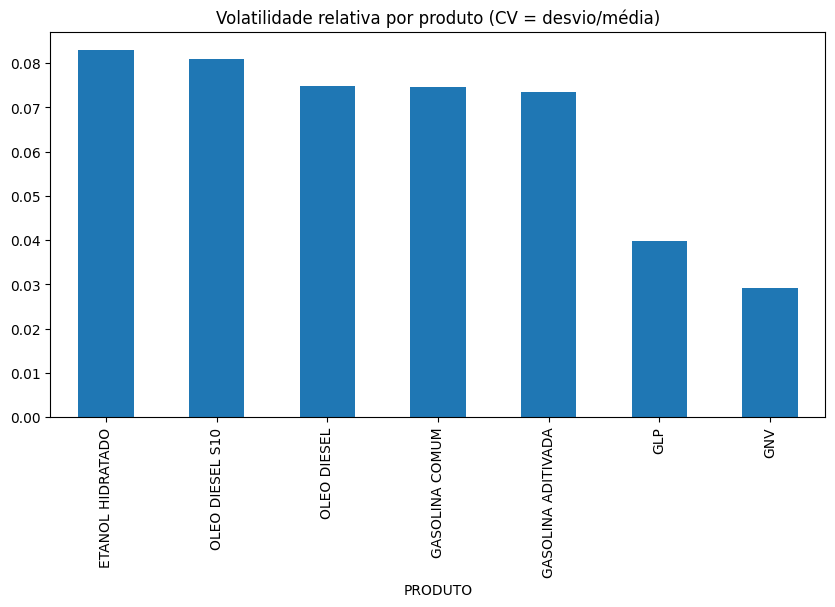

In [76]:
cv_por_produto = (
    df_brasil.groupby("PRODUTO")["PREÇO MÉDIO REVENDA"]
    .agg(lambda x: x.std() / x.mean())
    .sort_values(ascending=False)
)
cv_por_produto.plot(kind="bar", figsize=(10, 5), title="Volatilidade relativa por produto (CV = desvio/média)")

## 5. Interpretação

- **Dado limpo desde a origem:** zero nulos, zero duplicatas, zero violação de mín≤médio≤máx em 445 mil linhas.
- **Tipagem e normalização de texto já corretas**: nenhum tratamento adicional necessário.
- **Unidades distintas por produto:** GLP (R$/13kg) e GNV (R$/m³) não são comparáveis diretamente com os demais (R$/litro).
- **Distribuição de preços condizente com o mercado real** (etanol mais barato, diesel S10 levemente acima do comum).
- **Salto de preço em 2023 e jan/2026** salto de 2023 coincide com um período de mudanças simultâneas na política de preços (fim do PPI da Petrobras, com corte de preços na refinaria) e tributária (reoneração de PIS/Cofins sobre combustíveis, retomada gradual ao longo do ano). Aumeto de jan/2026 corresponde a aumento real de ICMS (Confaz).
- **Implicação para modelagem:** eventos tributários pontuais quebram a série temporal; um modelo baseado só em lags de preço tende a errar mais perto desses eventos.

